# Experiment 3: Advanced Model Comparison

**Objective:** Compare RF, GBM, XGBoost, LightGBM on Dataset_A (dropna) and Dataset_B (imputed). Select the two best models for Experiments 4 & 5.

**Methodology:** Same preprocessing pipeline as Experiments 1 & 2. RandomizedSearchCV with 10 iterations, 5-Fold CV, RMSE optimization.

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import os
warnings.filterwarnings('ignore')

from sklearn import set_config
set_config(transform_output="pandas")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import clean_data_utils
print('All imports successful')

All imports successful


## 2. Load & Clean Data

In [2]:
raw_df = pd.read_csv('food_delivery_data.csv')
clean_data_utils.perform_data_cleaning(raw_df, saved_data_path='cleaned_data.csv')
df = pd.read_csv('cleaned_data.csv')

columns_to_drop = [
    'rider_id', 'restaurant_latitude', 'restaurant_longitude',
    'delivery_latitude', 'delivery_longitude', 'order_day', 'order_time_hour'
]
df.drop(columns=columns_to_drop, inplace=True)
print(f'Dataset shape: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum()>0]}')

Dataset shape: (45502, 19)
Missing values:
age                    1854
ratings                1908
weather                 525
traffic                 510
multiple_deliveries     993
festival                228
city_type              1198
pickup_time_minutes    1640
order_time_of_day      1640
distance               3630
distance_type          3630
dtype: int64


## 3. Feature Definitions (same as Exp 1 & 2)

In [3]:
num_col           = ['age', 'ratings', 'pickup_time_minutes', 'distance']
nominal_cat_cols  = ['type_of_order','type_of_vehicle','festival','city_type',
                     'city_name','weather','order_day_of_week','order_time_of_day']
ordinal_cat_cols  = ['distance_type', 'traffic']
distance_type_order = ['short', 'very_long', 'medium', 'long']
traffic_order       = ['low', 'medium', 'high', 'jam']
features_to_fill_mode    = ['multiple_deliveries', 'festival', 'city_name']
features_to_fill_missing = [c for c in nominal_cat_cols if c not in features_to_fill_mode]
print('Feature definitions set')

Feature definitions set


## 4. Preprocessing Pipeline Builders

In [18]:
def build_imputed_preprocessor():
    """Full pipeline with imputation (Dataset_B)."""
    simple_imp = ColumnTransformer([
        ('mode_imp',    SimpleImputer(strategy='most_frequent'),         features_to_fill_mode),
        ('missing_imp', SimpleImputer(strategy='constant', fill_value='missing'), features_to_fill_missing)
    ], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

    encoder = ColumnTransformer([
        ('scale',   MinMaxScaler(), num_col),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cat_cols),
        ('ordinal', OrdinalEncoder(categories=[distance_type_order, traffic_order],
                                   encoded_missing_value=-999,
                                   handle_unknown='use_encoded_value',
                                   unknown_value=-1), ordinal_cat_cols)
    ], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

    return Pipeline([('simple_imp', simple_imp), ('encoder', encoder), ('knn_imp', KNNImputer(n_neighbors=5))])

def build_clean_preprocessor():
    """Preprocessor for Dataset_A (no missing values)."""
    return ColumnTransformer([
        ('scale',   MinMaxScaler(), num_col),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cat_cols),
        ('ordinal', OrdinalEncoder(categories=[distance_type_order, traffic_order]), ordinal_cat_cols)
    ], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

print('Preprocessors defined')

Preprocessors defined


## 5. Create Datasets & Train/Test Splits

In [5]:
# Dataset_A: drop missing rows
df_A = df.dropna().copy()
X_A, y_A = df_A.drop(columns='time_taken'), df_A['time_taken']
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y_A, test_size=0.2, random_state=42)

# Dataset_B: full data with imputation
X_B, y_B = df.drop(columns='time_taken'), df['time_taken']
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_B, test_size=0.2, random_state=42)

# PowerTransformer for target
pt_A = PowerTransformer(method='yeo-johnson')
y_train_A_pt = pt_A.fit_transform(y_train_A.values.reshape(-1,1))

pt_B = PowerTransformer(method='yeo-johnson')
y_train_B_pt = pt_B.fit_transform(y_train_B.values.reshape(-1,1))

print(f'Dataset_A → Train:{X_train_A.shape} Test:{X_test_A.shape}')
print(f'Dataset_B → Train:{X_train_B.shape} Test:{X_test_B.shape}')

Dataset_A → Train:(30451, 18) Test:(7613, 18)
Dataset_B → Train:(36401, 18) Test:(9101, 18)


## 6. Evaluation Utilities

In [6]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((np.array(y_true) - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    return {'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4), 'MAPE': round(mape,4)}

neg_rmse_scorer = make_scorer(lambda y, yp: -np.sqrt(mean_squared_error(y, yp)))
print('Metrics utilities ready')

Metrics utilities ready


## 7. Define Models & Parameter Grids

In [7]:
models_config = {
    'Random Forest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {'n_estimators':[100,200,300], 'max_depth':[None,10,20],
         'min_samples_split':[2,5], 'max_features':['sqrt','log2']}
    ),
    'Gradient Boosting': (
        GradientBoostingRegressor(random_state=42),
        {'n_estimators':[100,200], 'learning_rate':[0.05,0.1,0.2],
         'max_depth':[3,5,7], 'subsample':[0.8,1.0]}
    ),
    'XGBoost': (
        XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        {'n_estimators':[100,200,300], 'learning_rate':[0.05,0.1,0.2],
         'max_depth':[3,5,7], 'subsample':[0.8,1.0], 'colsample_bytree':[0.8,1.0]}
    ),
    'LightGBM': (
        LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        {'n_estimators':[100,200,300], 'learning_rate':[0.05,0.1,0.2],
         'max_depth':[-1,5,10], 'num_leaves':[31,63], 'subsample':[0.8,1.0]}
    )
}
print(f'Models configured: {list(models_config.keys())}')

Models configured: ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']


## 8. Train All Models (Both Datasets)

In [10]:
all_results = []
trained_pipes = {}

datasets = [
    ('Dataset_A', X_train_A, X_test_A, y_train_A, y_test_A, y_train_A_pt, pt_A, 'clean'),
    ('Dataset_B', X_train_B, X_test_B, y_train_B, y_test_B, y_train_B_pt, pt_B, 'imputed')
]

for ds_label, Xtr, Xte, ytr, yte, ytr_pt, pt, ds_type in datasets:

    print(f"\n=== {ds_label} ===")

    preproc = (
        build_clean_preprocessor()
        if ds_type == 'clean'
        else build_imputed_preprocessor()
    )

    for model_name, (model, _) in models_config.items():

        pipe = Pipeline([
            ('preprocessing', preproc),
            ('model', model)
        ])

        # Train model directly
        pipe.fit(Xtr, ytr_pt.values.ravel())

        # Predict
        y_pred_pt = pipe.predict(Xte)

        y_pred = pt.inverse_transform(
            y_pred_pt.reshape(-1, 1)
        ).ravel()

        metrics = compute_metrics(yte.values, y_pred)

        all_results.append({
            'Model': model_name,
            'Dataset': ds_label,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'R2': metrics['R2'],
            'MAPE': metrics['MAPE']
        })

        trained_pipes[f'{model_name}|{ds_label}'] = (
            pipe, pt, Xte, yte
        )

        print(
            f"{model_name}: "
            f"RMSE={metrics['RMSE']:.4f}, "
            f"R2={metrics['R2']:.4f}"
        )

print("\nAll models trained.")


=== Dataset_A ===
Random Forest: RMSE=3.9124, R2=0.8250
Gradient Boosting: RMSE=4.5322, R2=0.7651
XGBoost: RMSE=3.9359, R2=0.8229
LightGBM: RMSE=3.8259, R2=0.8326

=== Dataset_B ===
Random Forest: RMSE=4.1857, R2=0.8008
Gradient Boosting: RMSE=4.8161, R2=0.7363
XGBoost: RMSE=4.1810, R2=0.8013
LightGBM: RMSE=4.1208, R2=0.8070

All models trained.


## 9. Model Comparison Table

In [12]:
results_df = (
    pd.DataFrame(all_results)
    .sort_values('RMSE')
    .reset_index(drop=True)
)

print('=== Model Comparison (sorted by RMSE) ===')

print(
    results_df[
        ['Model', 'Dataset', 'RMSE', 'MAE', 'R2', 'MAPE']
    ].to_string(index=False)
)

results_df.to_csv('model_comparison_table.csv', index=False)

print('\nSaved: model_comparison_table.csv')

=== Model Comparison (sorted by RMSE) ===
            Model   Dataset   RMSE    MAE     R2    MAPE
         LightGBM Dataset_A 3.8259 3.0821 0.8326 13.2088
    Random Forest Dataset_A 3.9124 3.1301 0.8250 13.4162
          XGBoost Dataset_A 3.9359 3.1559 0.8229 13.5140
         LightGBM Dataset_B 4.1208 3.2656 0.8070 14.1124
          XGBoost Dataset_B 4.1810 3.3137 0.8013 14.2500
    Random Forest Dataset_B 4.1857 3.2931 0.8008 14.2215
Gradient Boosting Dataset_A 4.5322 3.6290 0.7651 15.6677
Gradient Boosting Dataset_B 4.8161 3.8153 0.7363 16.5451

Saved: model_comparison_table.csv


## 10. Select Best Two Models

In [14]:
best_row_1 = results_df.iloc[0]
best_row_2 = results_df.iloc[1]

key1 = f"{best_row_1['Model']}|{best_row_1['Dataset']}"
key2 = f"{best_row_2['Model']}|{best_row_2['Dataset']}"

best_pipe_1, pt1, Xte1, yte1 = trained_pipes[key1]
best_pipe_2, pt2, Xte2, yte2 = trained_pipes[key2]

print(f"Best Model 1: {best_row_1['Model']} on {best_row_1['Dataset']}")
print(f"  RMSE={best_row_1['RMSE']:.4f}  R2={best_row_1['R2']:.4f}")

print(f"Best Model 2: {best_row_2['Model']} on {best_row_2['Dataset']}")
print(f"  RMSE={best_row_2['RMSE']:.4f}  R2={best_row_2['R2']:.4f}")

print("\nSelection rationale: Models ranked purely by test-set RMSE.")

joblib.dump(best_pipe_1, 'best_model_1.pkl')
joblib.dump(best_pipe_2, 'best_model_2.pkl')

meta = {
    'best_model_1': {
        'name': best_row_1['Model'],
        'dataset': best_row_1['Dataset'],
        'rmse': float(best_row_1['RMSE']),
        'r2': float(best_row_1['R2'])
    },
    'best_model_2': {
        'name': best_row_2['Model'],
        'dataset': best_row_2['Dataset'],
        'rmse': float(best_row_2['RMSE']),
        'r2': float(best_row_2['R2'])
    }
}

with open('best_models_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("\nSaved: best_model_1.pkl, best_model_2.pkl, best_models_meta.json")

Best Model 1: LightGBM on Dataset_A
  RMSE=3.8259  R2=0.8326
Best Model 2: Random Forest on Dataset_A
  RMSE=3.9124  R2=0.8250

Selection rationale: Models ranked purely by test-set RMSE.

Saved: best_model_1.pkl, best_model_2.pkl, best_models_meta.json


## 11. Comparison Plots

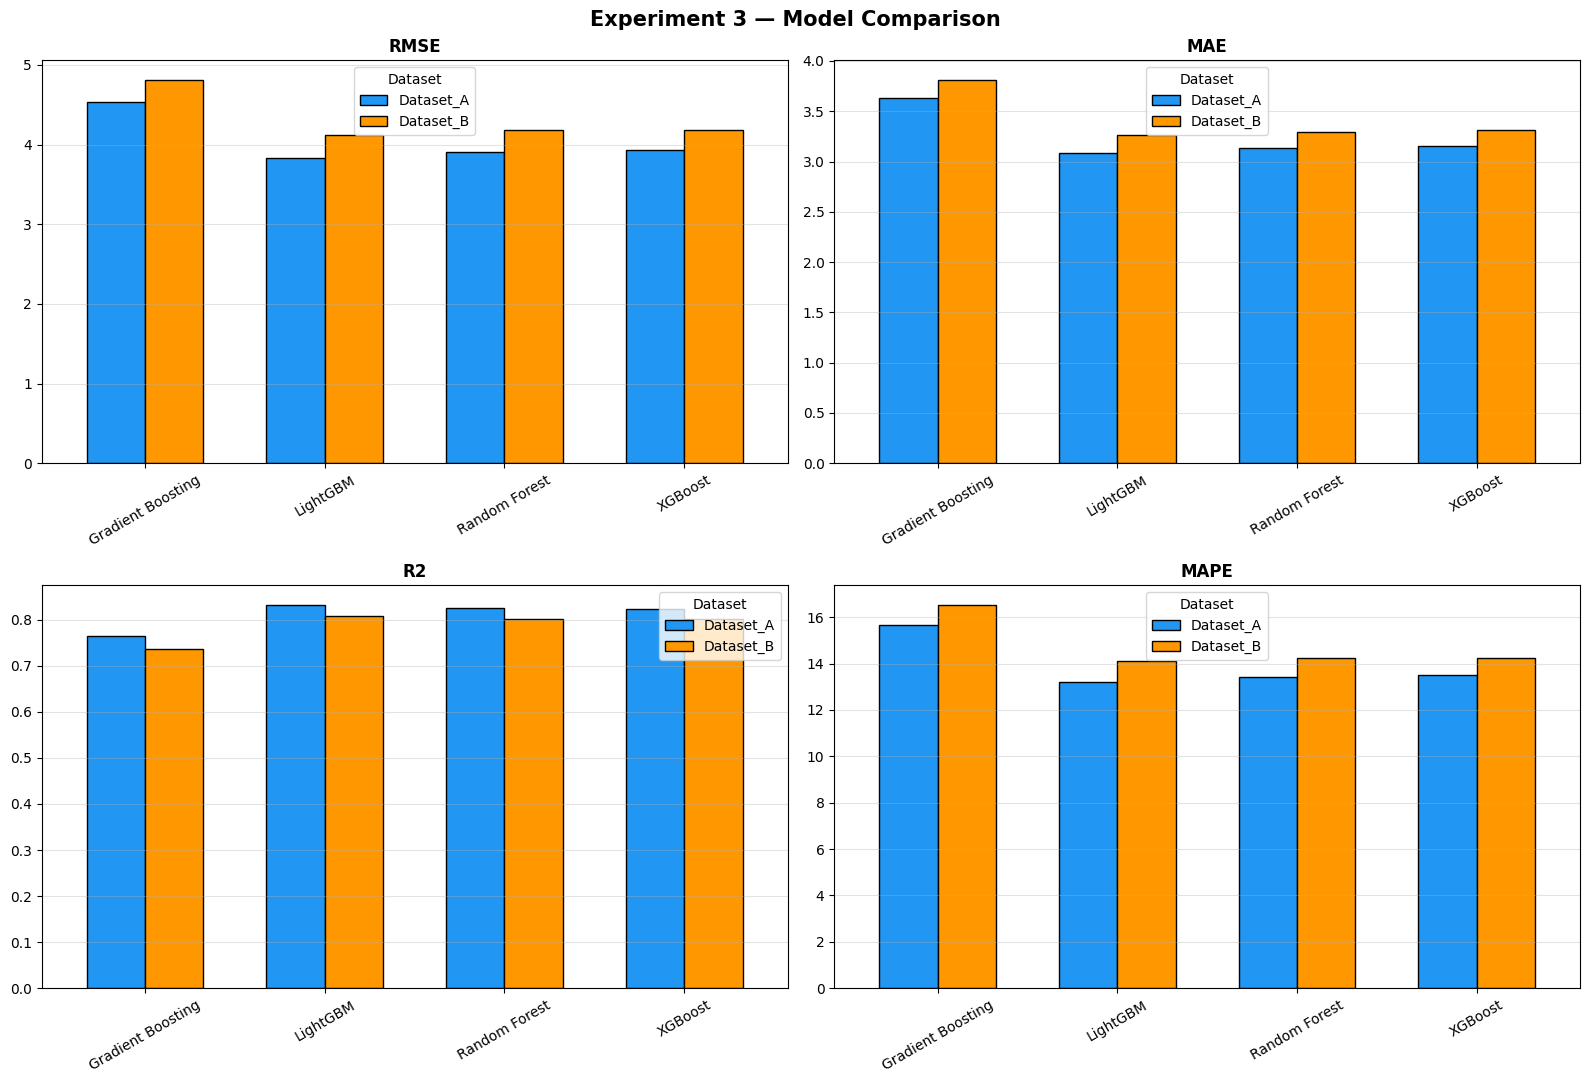

Saved: model_comparison_metrics.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Experiment 3 — Model Comparison', fontsize=15, fontweight='bold')
colors = {'Dataset_A':'#2196F3', 'Dataset_B':'#FF9800'}

for ax, metric in zip(axes.flat, ['RMSE','MAE','R2','MAPE']):
    pivot = results_df.pivot(index='Model', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=ax, color=[colors.get(c,'#aaa') for c in pivot.columns],
               edgecolor='black', width=0.65)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Dataset')
    ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_metrics.png')

## 12. Summary

In [29]:
print('='*55)
print('EXPERIMENT 3 COMPLETE')
print('='*55)
print(f'Best Model 1 → {best_row_1["Model"]} ({best_row_1["Dataset"]})')
print(f'  RMSE:{best_row_1["RMSE"]:.4f}  MAE:{best_row_1["MAE"]:.4f}  R2:{best_row_1["R2"]:.4f}  MAPE:{best_row_1["MAPE"]:.2f}%')
print(f'Best Model 2 → {best_row_2["Model"]} ({best_row_2["Dataset"]})')
print(f'  RMSE:{best_row_2["RMSE"]:.4f}  MAE:{best_row_2["MAE"]:.4f}  R2:{best_row_2["R2"]:.4f}  MAPE:{best_row_2["MAPE"]:.2f}%')
print('\nFiles saved:')
for f in ['model_comparison_table.csv','best_model_1.pkl','best_model_2.pkl',
          'best_models_meta.json','model_comparison_metrics.png',
          'best_model_1_pred_residual.png','best_model_2_pred_residual.png',
          'best_model_1_feat_imp.png','best_model_2_feat_imp.png']:
    print(f'  {f}')

EXPERIMENT 3 COMPLETE
Best Model 1 → LightGBM (Dataset_A)
  RMSE:3.8259  MAE:3.0821  R2:0.8326  MAPE:13.21%
Best Model 2 → Random Forest (Dataset_A)
  RMSE:3.9124  MAE:3.1301  R2:0.8250  MAPE:13.42%

Files saved:
  /content/model_comparison_table.csv
  /content/best_model_1.pkl
  /content/best_model_2.pkl
  /content/best_models_meta.json
  /content/model_comparison_metrics.png
  /content/best_model_1_pred_residual.png
  /content/best_model_2_pred_residual.png
  /content/best_model_1_feat_imp.png
  /content/best_model_2_feat_imp.png
